# UNSW-NB15 — Network Intrusion Detection
## Classification Track — Preprocessing & EDA (Review 1)

**Course:** 23CSE301 Machine Learning — Capstone Project
**Track:** Classification (this notebook covers Rubric **Section A: Dataset & EDA** and **Section B: Preprocessing & Feature Engineering**, which are the shared prerequisite steps before model training)
**Dataset:** UNSW-NB15 Intrusion Detection Dataset (`UNSW_NB15_training-set.csv`, `UNSW_NB15_testing-set.csv`)

### About the dataset
UNSW-NB15 is a network traffic dataset created by the Australian Centre for Cyber Security (ACCS). Each row is a network flow described by 42 numerical/categorical traffic features (duration, byte counts, TTLs, jitter, connection counts, etc.). Two label columns are provided:

- **`label`** — binary target: `0` = Normal traffic, `1` = Attack traffic.
- **`attack_cat`** — multi-class target: `Normal` or one of 9 attack categories (`Generic`, `Exploits`, `Fuzzers`, `DoS`, `Reconnaissance`, `Analysis`, `Backdoor`, `Shellcode`, `Worms`).

> **Note on tracks:** This dataset is a natural fit for the **Classification track** (it has categorical/binary ground-truth labels, not a continuous numeric target), so it will be used here for **Classification Part A / Part B**. The Regression track requires a separate dataset with a continuous target — this notebook does **not** cover regression preprocessing.

> **Chosen target for this pipeline:** We use **`attack_cat`** (multi-class) as the primary classification target, since it is the richer label and the rubric explicitly calls out multi-class handling (One-vs-Rest ROC-AUC). `label` is kept alongside as a binary reference target. Because `attack_cat` and `label` encode the same information (label = 0 exactly when attack_cat = 'Normal'), **whichever column is chosen as the target, the other must be dropped from the feature set** to avoid data leakage — this is handled explicitly below.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 60)


## Section A — Dataset & EDA

### A1. Dataset Loading & Audit
We load the officially provided train/test files, and report shape, dtypes, missing-value counts, and the target distribution.


In [2]:
train_df = pd.read_csv("data/raw/UNSW_NB15_training-set.csv")
test_df = pd.read_csv("data/raw/UNSW_NB15_testing-set.csv")

print("Training set shape:", train_df.shape)
print("Testing  set shape:", test_df.shape)
print()
print("Training set columns ({} total):".format(train_df.shape[1]))
print(list(train_df.columns))


Training set shape: (82332, 45)
Testing  set shape: (175341, 45)

Training set columns (45 total):
['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']


In [3]:
# Data types
train_df.dtypes.to_frame(name="dtype").T


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
dtype,int64,float64,str,str,str,int64,int64,int64,int64,float64,int64,int64,float64,float64,int64,int64,float64,float64,float64,float64,int64,int64,int64,int64,float64,float64,float64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,str,int64


In [4]:
# Standard missing-value audit (NaN / null)
missing_counts = train_df.isnull().sum()
print("Columns with NaN/null values (standard pandas check):")
print(missing_counts[missing_counts > 0] if missing_counts.sum() > 0 else "None found.")

# UNSW-NB15 encodes 'unknown/no-service-detected' as the string '-' in the
# 'service' column rather than a NaN. This is a domain-specific missing-value
# marker, so we audit it separately.
print()
print("Rows where service == '-' (i.e. missing/unknown service):")
print(f"  Train: {(train_df['service'] == '-').sum()} / {len(train_df)} "
      f"({(train_df['service'] == '-').mean()*100:.1f}%)")
print(f"  Test:  {(test_df['service'] == '-').sum()} / {len(test_df)} "
      f"({(test_df['service'] == '-').mean()*100:.1f}%)")


Columns with NaN/null values (standard pandas check):
None found.

Rows where service == '-' (i.e. missing/unknown service):
  Train: 47153 / 82332 (57.3%)
  Test:  94168 / 175341 (53.7%)


In [5]:
# Target distribution — binary label
print("Binary target ('label') distribution — Training set:")
print(train_df["label"].value_counts())
print((train_df["label"].value_counts(normalize=True) * 100).round(2).astype(str) + " %")
print()
print("Multi-class target ('attack_cat') distribution — Training set:")
print(train_df["attack_cat"].value_counts())


Binary target ('label') distribution — Training set:
label
1    45332
0    37000
Name: count, dtype: int64
label
1    55.06 %
0    44.94 %
Name: proportion, dtype: str

Multi-class target ('attack_cat') distribution — Training set:
attack_cat
Normal            37000
Generic           18871
Exploits          11132
Fuzzers            6062
DoS                4089
Reconnaissance     3496
Analysis            677
Backdoor            583
Shellcode           378
Worms                44
Name: count, dtype: int64


**Observation (A1):** The training set has **82,332 rows and 45 columns** (43 features + `id` + two target columns `attack_cat`/`label`); the test set has **175,341 rows**. There are **no standard NaN values** anywhere in the data, but the `service` column uses the placeholder string `'-'` for "no service detected", which affects **~57% of training rows** — this must be treated as a meaningful missing-value marker in Section B, not ignored. The binary target is imbalanced but not severely (`Attack` 55% vs `Normal` 45%), while the multi-class target `attack_cat` is **highly imbalanced**: `Normal` (37,000) and `Generic` (18,871) dominate, while `Worms` has only 44 samples — this will need to be flagged for the modelling stage (e.g. stratified splitting, weighted metrics).


### A2. EDA Visualisations

We now visualise: (i) feature distributions, (ii) a correlation heatmap, (iii) target distributions, and (iv) feature-vs-target scatter plots.


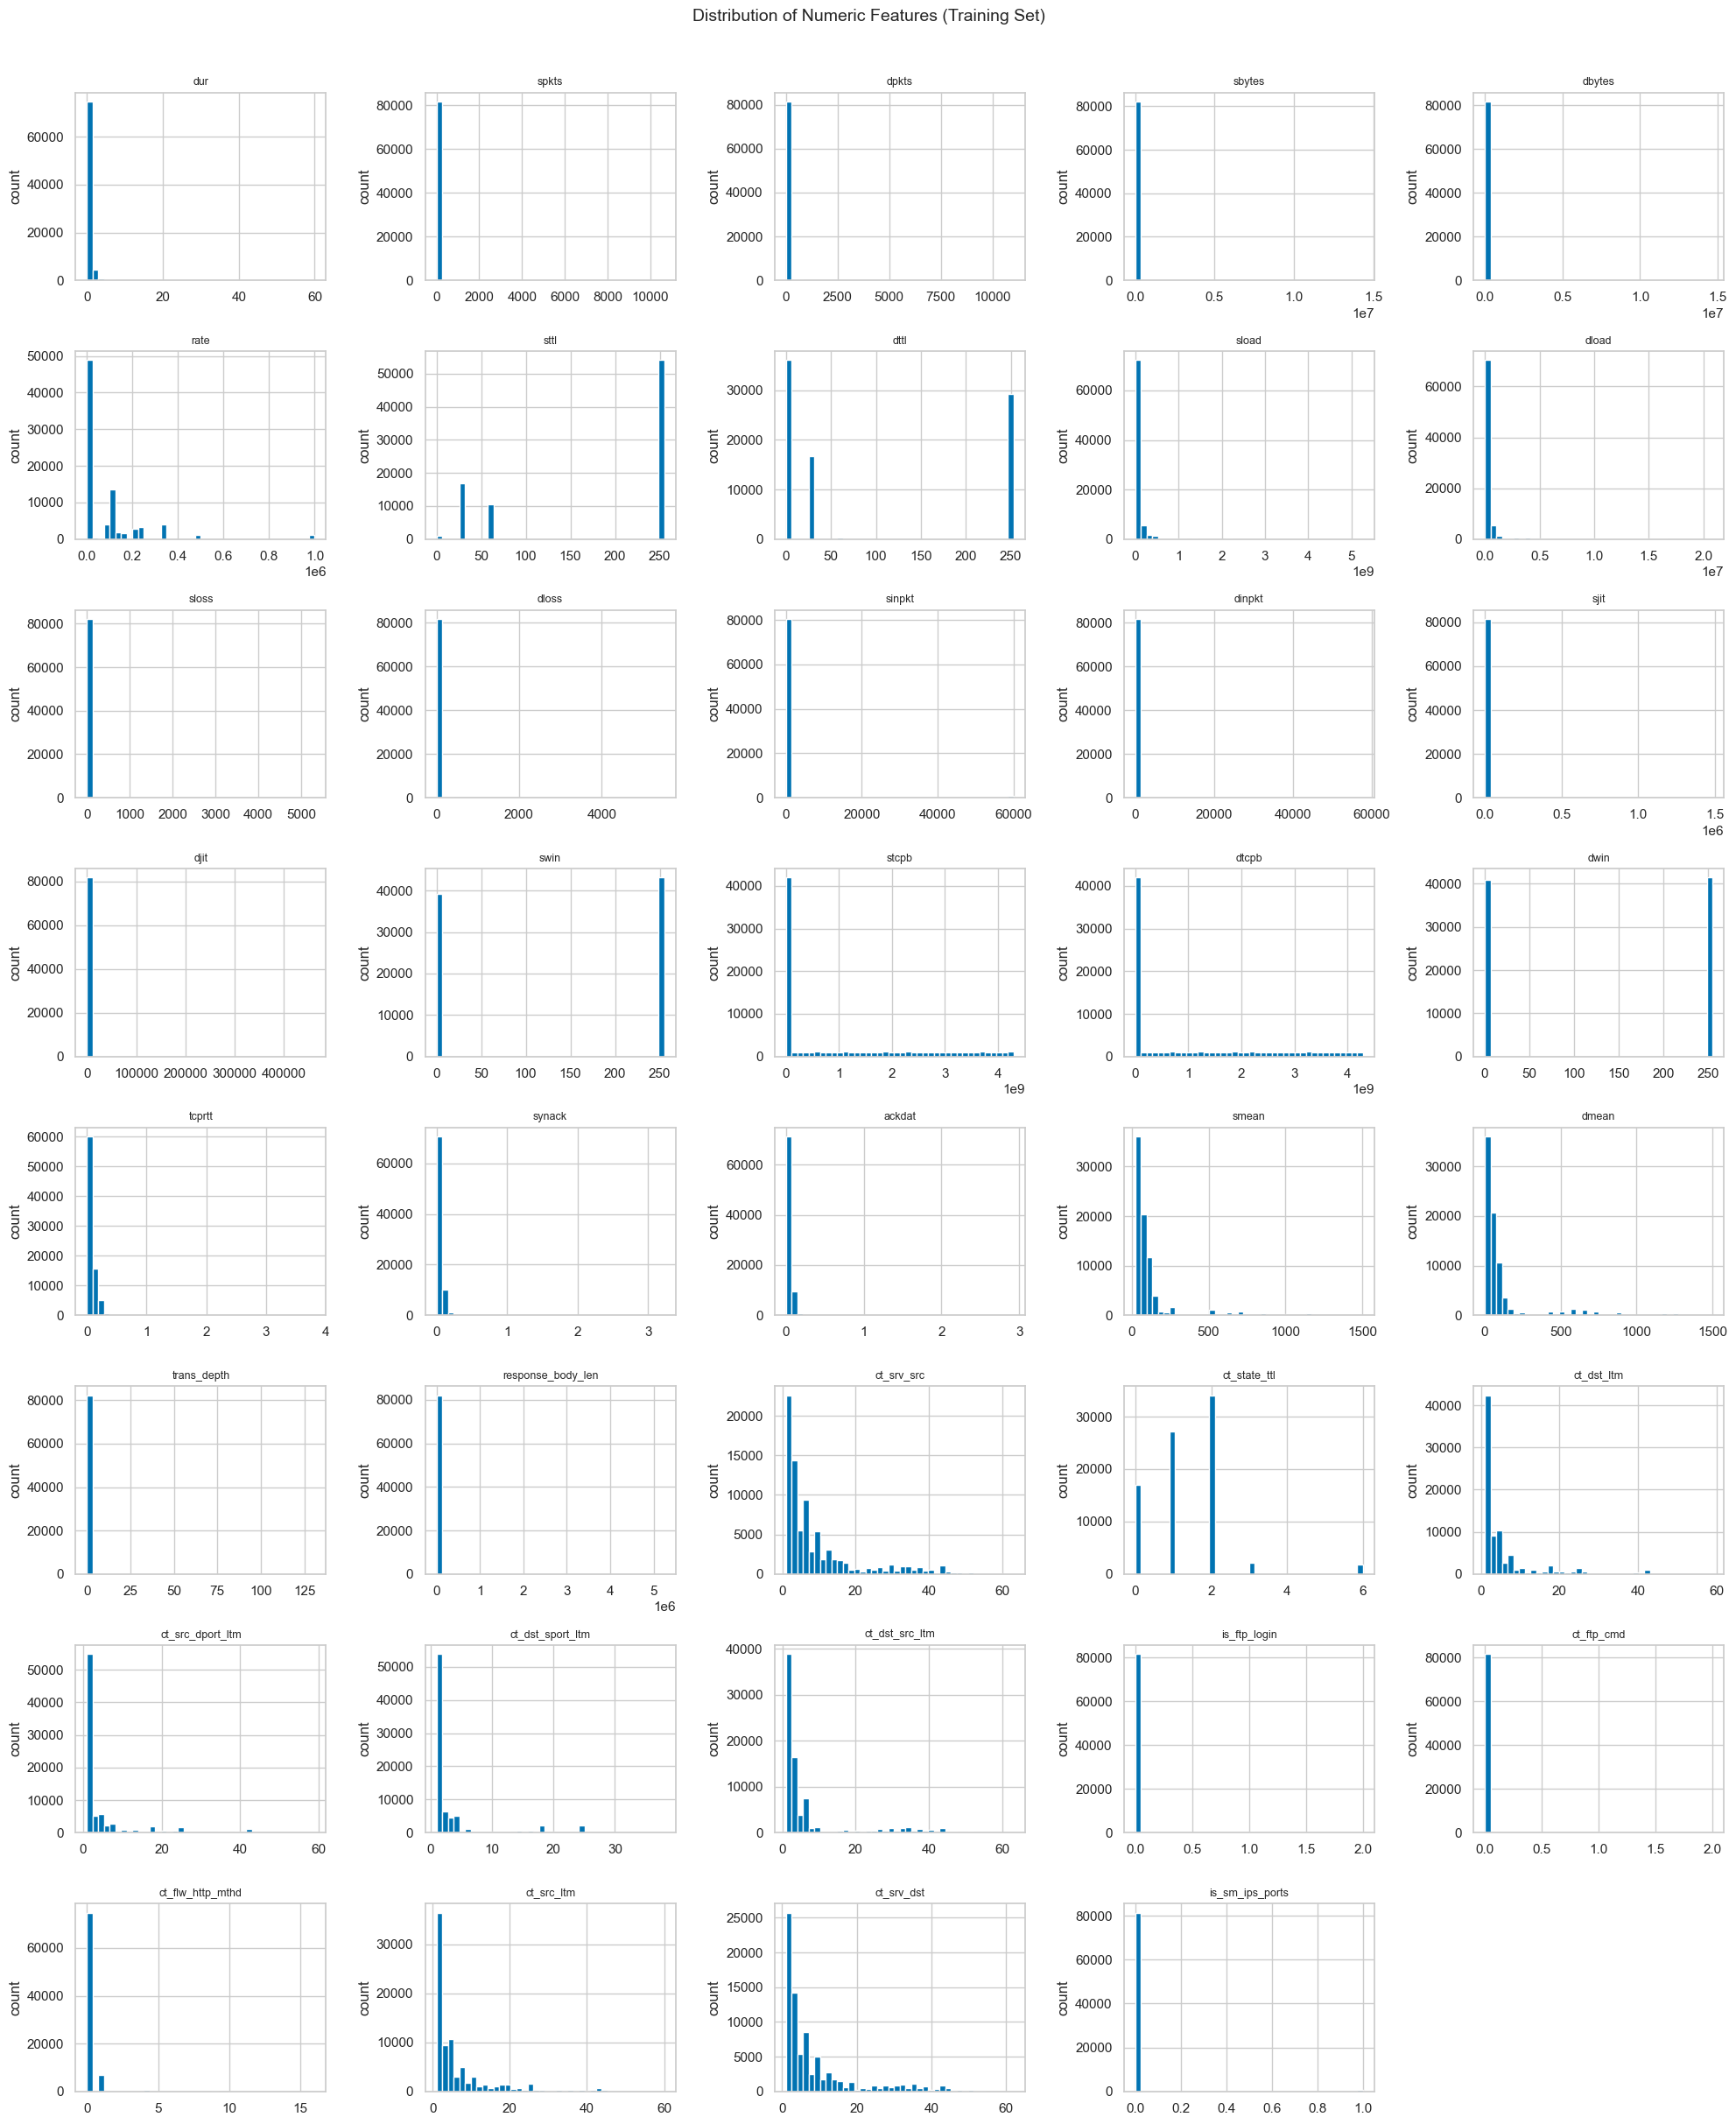

In [6]:
# (i) Distribution plots for each numeric feature (grid of histograms)
numeric_cols = train_df.select_dtypes(include=[np.number]).columns.drop(["id", "label"])
n_cols = 5
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    axes[i].hist(train_df[col], bins=40, color=sns.color_palette("colorblind")[0])
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("count")
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])
fig.suptitle("Distribution of Numeric Features (Training Set)", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("eda_feature_distributions.png", bbox_inches="tight")
plt.show()


**Observation (A2-i):** Most traffic-volume features (`sbytes`, `dbytes`, `sload`, `dload`, `sinpkt`, `dur`, etc.) are **extremely right-skewed** — a small number of flows carry very large byte counts / rates while the vast majority are near zero. Several columns (`is_ftp_login`, `ct_ftp_cmd`, `is_sm_ips_ports`, `trans_depth`) are effectively **near-constant / sparse binary-like indicators**. This skew tells us we should consider log-transforms or robust scaling for the heavy-tailed columns during preprocessing.


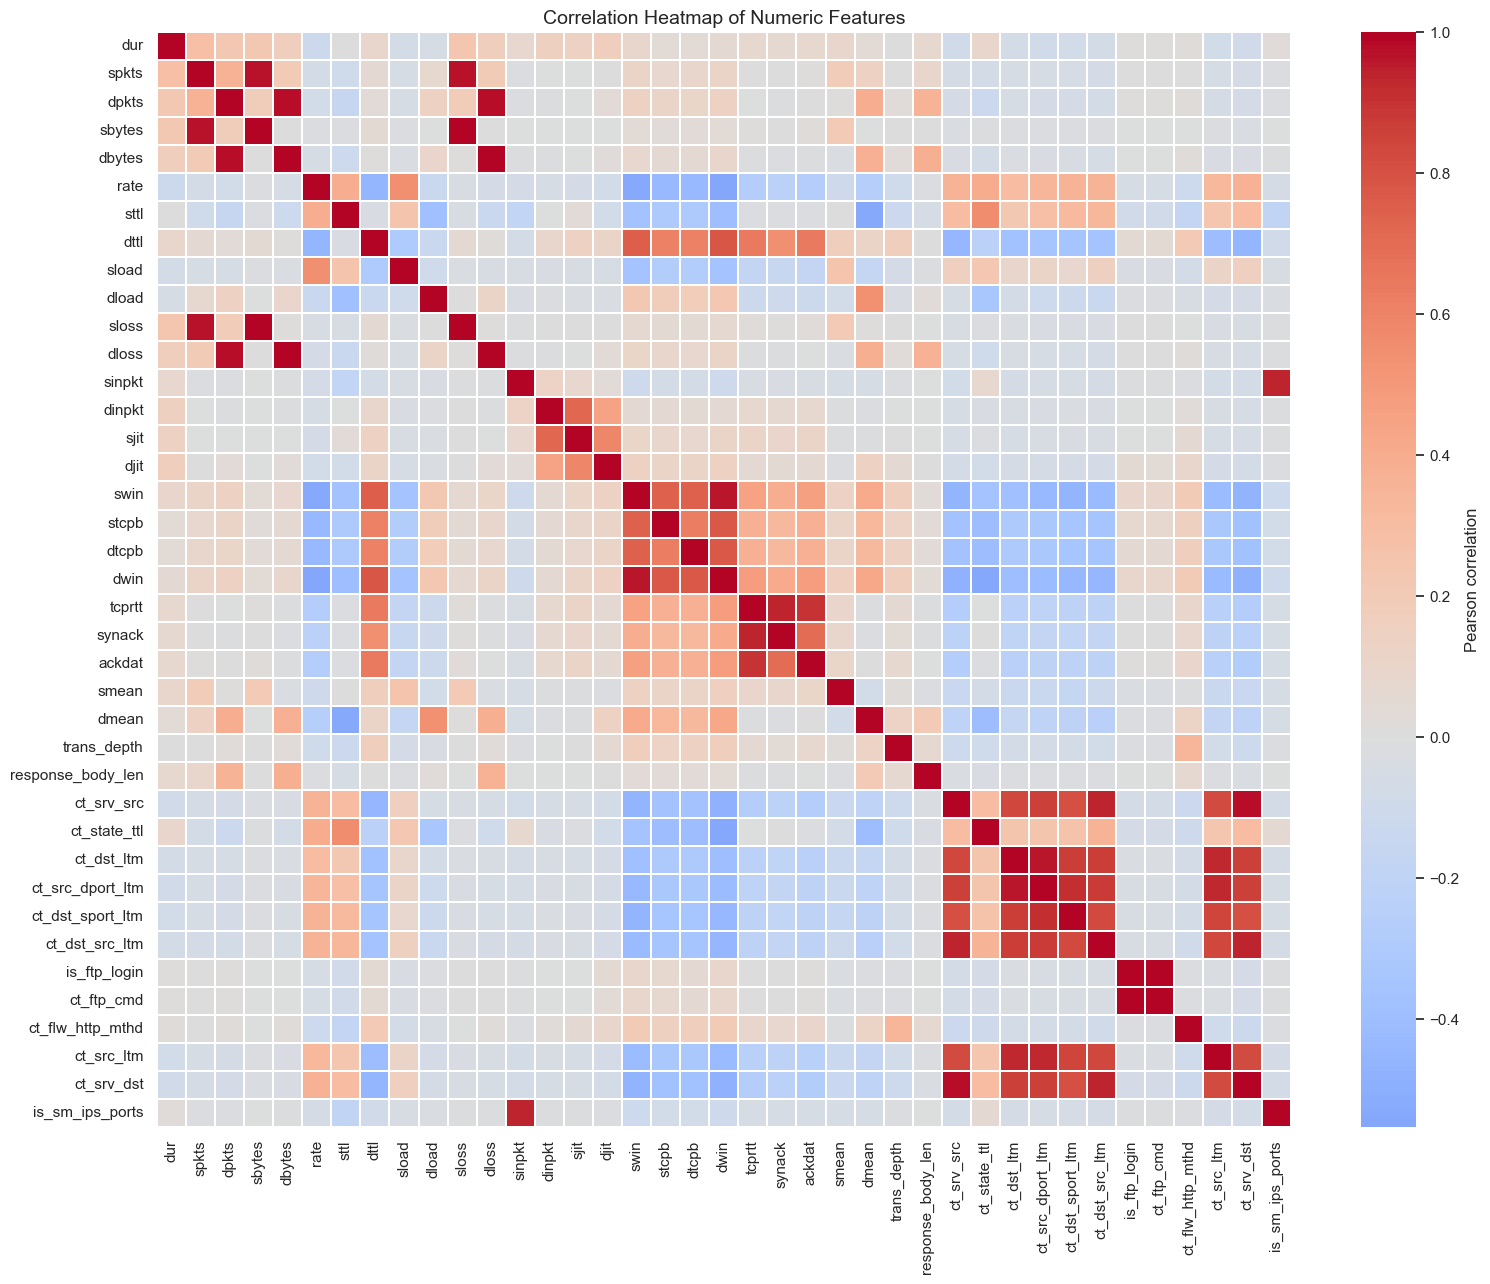

In [7]:
# (ii) Correlation heatmap
corr = train_df[numeric_cols].corr()
plt.figure(figsize=(16, 13))
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.3,
            cbar_kws={"label": "Pearson correlation"})
plt.title("Correlation Heatmap of Numeric Features", fontsize=14)
plt.tight_layout()
plt.savefig("eda_correlation_heatmap.png", bbox_inches="tight")
plt.show()


**Observation (A2-ii):** There are several tightly correlated feature clusters, e.g. `sload`/`dload` with `sbytes`/`dbytes`/`rate`, and `ct_srv_src`/`ct_srv_dst`/`ct_src_ltm`/`ct_dst_ltm` (the "connection count in last N flows" family) which are mutually highly correlated since they all count related historical-connection statistics. `swin` and `dwin` are almost perfectly correlated. This multicollinearity is useful to know for regularised linear models (Ridge/Lasso) later, and suggests candidate features for feature engineering / dimensionality reduction.

Ridge: tends to share the weight between correlated features.
Lasso: may give most of the weight to one and push the other toward 0.
Elastic Net: combines both behaviors and often handles correlated features better


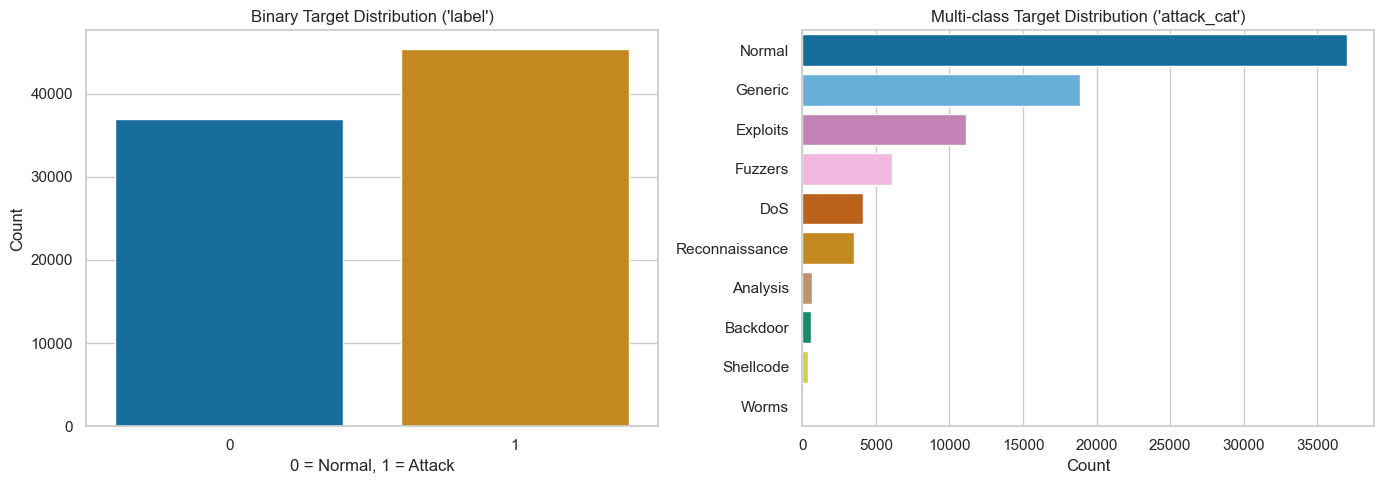

In [ ]:
# (iii) Target distribution plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x="label", data=train_df, ax=axes[0], hue="label", legend=False,
              palette="colorblind")
axes[0].set_title("Binary Target Distribution ('label')")
axes[0].set_xlabel("0 = Normal, 1 = Attack")
axes[0].set_ylabel("Count")

order = train_df["attack_cat"].value_counts().index
sns.countplot(y="attack_cat", data=train_df, order=order, ax=axes[1],
              hue="attack_cat", legend=False, palette="colorblind")
axes[1].set_title("Multi-class Target Distribution ('attack_cat')")
axes[1].set_xlabel("Count")
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig("eda_target_distribution.png", bbox_inches="tight")
plt.show()


**Observation (A2-iii):** The binary target is reasonably balanced. The multi-class target is severely imbalanced — the four rarest classes (`Analysis`, `Backdoor`, `Shellcode`, `Worms`) together make up under 2% of the data. This confirms we should use **stratified splitting** and **weighted F1 / macro metrics** rather than raw accuracy when evaluating multi-class classifiers later.


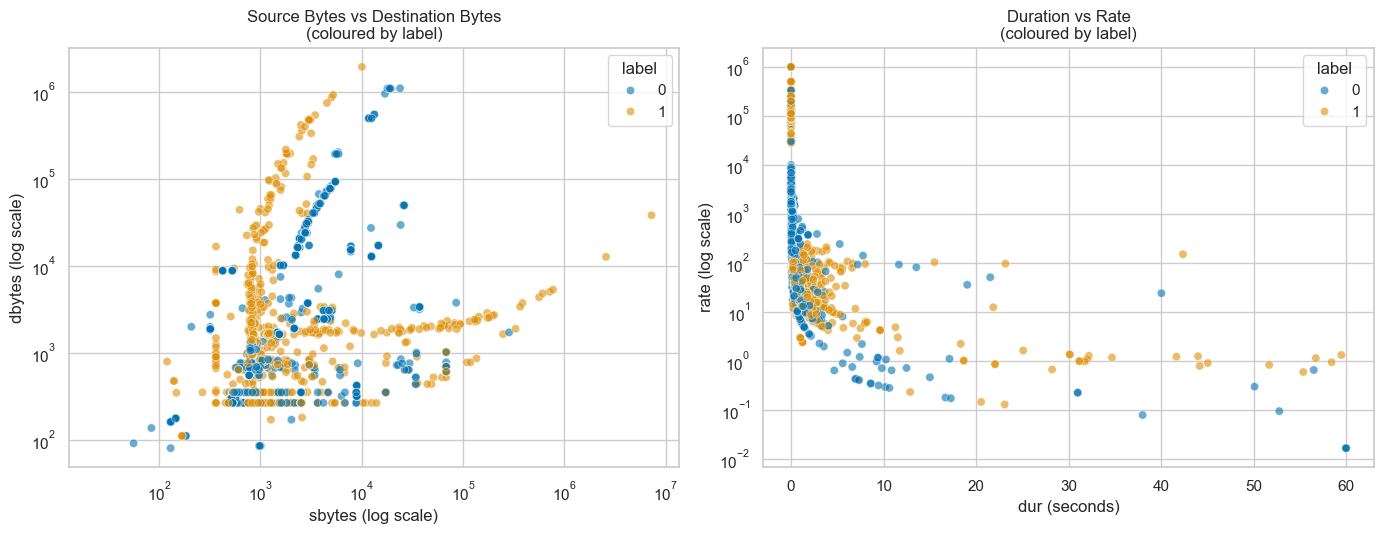

In [9]:
# (iv) Scatter plots: feature vs feature, coloured by target
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

sample = train_df.sample(4000, random_state=RANDOM_STATE)

sns.scatterplot(data=sample, x="sbytes", y="dbytes", hue="label",
                 palette="colorblind", alpha=0.6, ax=axes[0])
axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set_title("Source Bytes vs Destination Bytes\n(coloured by label)")
axes[0].set_xlabel("sbytes (log scale)")
axes[0].set_ylabel("dbytes (log scale)")

sns.scatterplot(data=sample, x="dur", y="rate", hue="label",
                 palette="colorblind", alpha=0.6, ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("Duration vs Rate\n(coloured by label)")
axes[1].set_xlabel("dur (seconds)")
axes[1].set_ylabel("rate (log scale)")

plt.tight_layout()
plt.savefig("eda_scatter_feature_target.png", bbox_inches="tight")
plt.show()


**Observation (A2-iv):** In the `sbytes` vs `dbytes` plot, attack traffic (label=1) clusters more towards very low `dbytes` for a given `sbytes` (i.e. lots of outbound data with little response), which is consistent with scanning/flooding-type attacks. In the `dur` vs `rate` plot, attack flows tend to concentrate at very short durations with a wide spread of rates, whereas normal traffic occupies a broader duration range — both scatter plots show that even two raw features already carry visible separation between classes, motivating the use of these engineered/normalised features in modelling.



xample Scenarios
Scenario	rate	dur	Total Packets	Type
Port scan	Very High (1000 pkt/s)	Very Low (2 sec)	2,000	Attack
File download	Medium (100 pkt/s)	High (50 sec)	5,000	Normal
Video stream	Medium (50 pkt/s)	Very High (300 sec)	15,000	Normal
Ping	Low (1 pkt/s)	Low (5 sec)	5	Normal

## Section B — Preprocessing & Feature Engineering

### B1. Data Cleaning
We treat: (1) the `'-'` placeholder in `service` as a meaningful missing-value category, (2) duplicate rows, and (3) outliers in heavy-tailed numeric columns.


In [10]:
# --- (1) Missing values: the '-' in `service` ---
# Strategy: rather than imputing with the mode (which would fabricate a false
# service label for ~57% of rows) or dropping these rows (which would discard
# more than half the data), we treat "no service detected" as its own valid
# category, since in network-traffic terms it IS informative (many attack
# flows genuinely don't complete a service handshake). We simply rename it to
# a clearer label so it survives one-hot encoding as an explicit category.
for df_ in (train_df, test_df):
    df_["service"] = df_["service"].replace("-", "no_service")

print("Unique service values after cleaning:", sorted(train_df["service"].unique()))


Unique service values after cleaning: ['dhcp', 'dns', 'ftp', 'ftp-data', 'http', 'irc', 'no_service', 'pop3', 'radius', 'smtp', 'snmp', 'ssh', 'ssl']


In [11]:
# --- (2) Duplicate rows ---
dup_train = train_df.duplicated().sum()
dup_test = test_df.duplicated().sum()
print(f"Duplicate rows -> train: {dup_train}, test: {dup_test}")

train_df = train_df.drop_duplicates().reset_index(drop=True)
test_df = test_df.drop_duplicates().reset_index(drop=True)
print("Shapes after de-duplication:", train_df.shape, test_df.shape)


Duplicate rows -> train: 0, test: 0


Shapes after de-duplication: (82332, 45) (175341, 45)


In [12]:
# --- (3) Outlier treatment: DEFERRED until AFTER the train/validation split ---
# Rationale: IQR-based capping must be fitted (its bounds computed) on the
# TRAINING split only. If we computed the bounds here on the full training
# file, the rows that later become the validation fold would have influenced
# the caps -> a (mild) form of data leakage. So the actual capping is applied
# in Section B2, immediately after the split, using bounds from X_train only.
# Here we only *list* the heavy-tailed columns we intend to cap.
skewed_cols = ["dur", "sbytes", "dbytes", "rate", "sload", "dload",
               "sloss", "dloss", "sinpkt", "dinpkt", "sjit", "djit"]
print("Columns flagged for outlier capping (applied after the split):")
print(skewed_cols)


Columns flagged for outlier capping (applied after the split):
['dur', 'sbytes', 'dbytes', 'rate', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit']


**Observation (B1):** No exact duplicate rows were found in either file, so no rows were dropped on that account. The `'-'` service placeholder was recoded to an explicit `no_service` category rather than imputed or dropped, since it is itself informative for attack detection. Outlier treatment on the heavy-tailed traffic columns is **intentionally deferred to after the train/validation split** (Section B2) so that the IQR bounds are computed from the training fold only — computing them here on the full training file would let validation rows influence the caps, a subtle leakage that the rubric penalises.


### B2. Encoding, Splitting, Outlier Capping & Scaling

The order of operations here is deliberate and leakage-safe:

1. **Encode** categoricals (`proto` rare-grouped, then one-hot) with the dummy columns fixed on the **training file only**; the test file is aligned to those same columns.
2. **Split** a stratified 80/20 train/validation set out of the training file (the provided test file stays as the untouched final hold-out).
3. **Cap outliers** on the heavy-tailed numeric columns using IQR bounds computed on **`X_train` only**, then apply the same bounds to validation and test.
4. **Engineer features** (Section B3) from the *raw, unscaled* values.
5. **Scale** all numeric features (including the engineered ones) with a `StandardScaler` **fit on `X_train` only**.

This guarantees no validation/test information ever influences any fitted transform, and that engineered ratios/differences are computed on real values before scaling.


In [13]:
# --- Categorical encoding ---
# Drop the 'id' column (row identifier, not a feature).
train_df = train_df.drop(columns=["id"])
test_df = test_df.drop(columns=["id"])

# Group rare protocols (frequency < 1% in TRAIN) into 'other' to avoid an
# explosion of one-hot columns and near-empty categories that generalise poorly.
proto_freq = train_df["proto"].value_counts(normalize=True)
common_protos = proto_freq[proto_freq >= 0.01].index.tolist()
print(f"Keeping {len(common_protos)} protocol categories as-is; grouping the rest into 'other'.")

for df_ in (train_df, test_df):
    df_["proto"] = df_["proto"].where(df_["proto"].isin(common_protos), "other")

categorical_cols = ["proto", "service", "state"]
print({c: train_df[c].nunique() for c in categorical_cols})


Keeping 4 protocol categories as-is; grouping the rest into 'other'.
{'proto': 5, 'service': 13, 'state': 7}


In [14]:
# Choose the classification target explicitly, and drop the OTHER target
# column from the features to prevent leakage (attack_cat <-> label are
# directly derived from one another).
TARGET_COL = "attack_cat"          # multi-class target used going forward
LEAK_COL = "label"                 # kept aside separately, not used as a feature

y_full = train_df[TARGET_COL].copy()
y_full_binary = train_df[LEAK_COL].copy()          # retained for optional binary-task use
y_test_full = test_df[TARGET_COL].copy()
y_test_full_binary = test_df[LEAK_COL].copy()

X_full = train_df.drop(columns=[TARGET_COL, LEAK_COL])
X_test_full = test_df.drop(columns=[TARGET_COL, LEAK_COL])

print("Feature matrix shape (train):", X_full.shape)
print("Feature matrix shape (test): ", X_test_full.shape)


Feature matrix shape (train): (82332, 42)
Feature matrix shape (test):  (175341, 42)


In [15]:
# One-hot encode categorical columns, fitting the set of dummy columns on
# TRAIN only, then aligning test to the same columns (any unseen category in
# test collapses to all-zero dummies rather than creating new columns).
X_full_enc = pd.get_dummies(X_full, columns=categorical_cols, drop_first=False)
X_test_enc = pd.get_dummies(X_test_full, columns=categorical_cols, drop_first=False)

# Align test columns to the training columns exactly (fit on train only).
X_test_enc = X_test_enc.reindex(columns=X_full_enc.columns, fill_value=0)

print("Encoded feature matrix shape (train):", X_full_enc.shape)
print("Encoded feature matrix shape (test): ", X_test_enc.shape)


Encoded feature matrix shape (train): (82332, 64)
Encoded feature matrix shape (test):  (175341, 64)


In [16]:
# --- Stratified train/validation split (80/20) from the training data ---
X_train, X_val, y_train, y_val = train_test_split(
    X_full_enc, y_full,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_full
)

print("Train:", X_train.shape, " Val:", X_val.shape)
print()
print("Class balance preserved after stratified split (train vs val, %):")
comp = pd.concat([
    y_train.value_counts(normalize=True).rename("train"),
    y_val.value_counts(normalize=True).rename("val")
], axis=1) * 100
print(comp.round(2))


Train: (65865, 64)  Val: (16467, 64)

Class balance preserved after stratified split (train vs val, %):
                train    val
attack_cat                  
Normal          44.94  44.94
Generic         22.92  22.92
Exploits        13.52  13.52
Fuzzers          7.36   7.36
DoS              4.97   4.97
Reconnaissance   4.25   4.24
Analysis         0.82   0.82
Backdoor         0.71   0.71
Shellcode        0.46   0.46
Worms            0.05   0.05


In [17]:
# --- Step 3: Outlier capping — bounds computed on X_train ONLY ---
# We cap only the heavy-tailed numeric columns listed in B1 that survive into
# the encoded matrix (the categorical originals are now one-hot columns).
cap_cols = [c for c in skewed_cols if c in X_train.columns]

outlier_bounds = {}
for col in cap_cols:
    q1, q3 = X_train[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outlier_bounds[col] = (lower, upper)

for col, (lower, upper) in outlier_bounds.items():
    X_train[col] = X_train[col].clip(lower, upper)
    X_val[col]   = X_val[col].clip(lower, upper)     # same train-derived bounds
    X_test_enc[col] = X_test_enc[col].clip(lower, upper)

print(f"Capped {len(cap_cols)} heavy-tailed columns using IQR bounds from X_train only.")
print("Same bounds applied (transform-only) to validation and test.")


Capped 12 heavy-tailed columns using IQR bounds from X_train only.
Same bounds applied (transform-only) to validation and test.


In [ ]:
# --- Step 4: Feature engineering on RAW (unscaled) values ---
# IMPORTANT: these are computed BEFORE scaling so that ratios/differences use
# real byte/TTL values and remain interpretable. They are scaled together with
# everything else in the next step.
def engineer_features(df):
    df = df.copy()

    # Normal traffic:  Balanced ratio (request ↔ response)
    # Attack traffic:  Extreme ratio (one-directional)
    # 1. Byte ratio: source bytes relative to destination bytes.
    #    Attack flows (scanning/DoS) often send much outbound but receive
    #    little back, giving an extreme ratio vs. balanced normal traffic.
    df["byte_ratio"] = df["sbytes"] / (df["dbytes"] + 1)

    # 2. Total packets per second: a flow-intensity signal comparable across
    #    flows of very different lengths.
    df["total_pkts_rate"] = (df["spkts"] + df["dpkts"]) / (df["dur"] + 1e-3)
    # What it captures: Flow intensity (packets per second)

    # Traffic Type	Total Packets	Duration	Rate	Interpretation
    # Normal web browsing	~50	~10s	5 pkt/s	Steady, moderate
    # File transfer	~1000	~60s	16 pkt/s	Sustained, efficient
    # Port scan	~1000	~2s	500 pkt/s	Burst flood
    # DoS attack	~10000	~5s	2000 pkt/s	Extreme flood
    # Why it matters:
    # Normal traffic:  Low-moderate rate (human-paced)
    # Attack traffic:  Very high rate (machine-generated flood)

    # 3. TTL difference: spoofed/crafted attack packets often show unusual or
    #    asymmetric TTLs vs. normal client-server traffic.
    df["ttl_diff"] = df["sttl"] - df["dttl"]

    return df

X_train = engineer_features(X_train)
X_val   = engineer_features(X_val)
X_test_enc = engineer_features(X_test_enc)

print("Engineered features (on raw values):", ["byte_ratio", "total_pkts_rate", "ttl_diff"])
print("Shapes -> train:", X_train.shape, " val:", X_val.shape, " test:", X_test_enc.shape)


Engineered features (on raw values): ['byte_ratio', 'total_pkts_rate', 'ttl_diff']
Shapes -> train: (65865, 67)  val: (16467, 67)  test: (175341, 67)


In [19]:
# --- Step 5: Scaling — StandardScaler fit on X_train ONLY (engineered cols included) ---
# Scale continuous columns (exclude boolean one-hot dummies and binary 0/1
# indicators, which are already on a comparable 0/1 scale).
numeric_feature_cols = [c for c in X_train.columns
                         if X_train[c].dtype != "bool" and X_train[c].nunique() > 2]

scaler = StandardScaler()
scaler.fit(X_train[numeric_feature_cols])          # fit on train ONLY

X_train_scaled = X_train.copy()
X_val_scaled   = X_val.copy()
X_test_scaled  = X_test_enc.copy()

X_train_scaled[numeric_feature_cols] = scaler.transform(X_train[numeric_feature_cols])
X_val_scaled[numeric_feature_cols]   = scaler.transform(X_val[numeric_feature_cols])
X_test_scaled[numeric_feature_cols]  = scaler.transform(X_test_enc[numeric_feature_cols])

print(f"Scaled {len(numeric_feature_cols)} continuous columns (incl. the 3 engineered ones).")
print("Scaler fit on X_train ONLY; validation and test were transform-only.")


Scaled 41 continuous columns (incl. the 3 engineered ones).
Scaler fit on X_train ONLY; validation and test were transform-only.


**Observation (B2):** Rare protocols (`proto` categories under 1% frequency) were grouped into `"other"` to avoid dozens of near-empty one-hot columns that overfit and don't generalise. The pipeline now runs in the leakage-safe order **encode → split → cap → engineer → scale**: the split happens before any fitting step, IQR caps and the `StandardScaler` are fit on `X_train` only (validation/test are transform-only), and the engineered features are created from *raw* values and then scaled alongside everything else. The stratified 80/20 split preserves the highly imbalanced class proportions almost exactly across train and validation — essential given how rare classes like `Worms` and `Shellcode` are.


### B3. Feature Engineering — Notes & Justification

The three engineered features were created in **Step 4 above** (before scaling, on raw values). This section documents and inspects them.

| Feature | Definition | Why it may help |
|---|---|---|
| `byte_ratio` | `sbytes / (dbytes + 1)` | Attacks like scanning/DoS send lots of outbound data with little response, producing an extreme ratio vs. balanced normal traffic. |
| `total_pkts_rate` | `(spkts + dpkts) / (dur + 1e-3)` | A single flow-intensity signal comparable across flows of very different durations. |
| `ttl_diff` | `sttl - dttl` | Spoofed/crafted attack packets often show unusual or asymmetric TTLs vs. normal client-server traffic. |


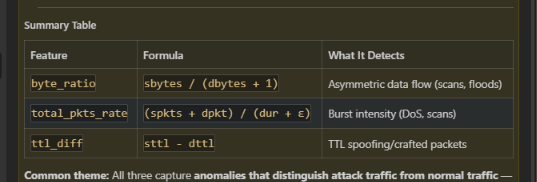

In [20]:
# Inspect the engineered features on the raw (pre-scaling) training split.
X_train[["byte_ratio", "total_pkts_rate", "ttl_diff"]].describe()


,byte_ratio,total_pkts_rate,ttl_diff
count,65865.000000,65865.000000,65865.000000
mean,115.266489,1278.723755,85.378000
std,326.143336,1320.662778,157.186412
min,0.105221,1.111920,-191.000000
25%,1.229866,32.068807,2.000000
50%,5.310782,1932.367150,2.000000
75%,114.000000,1986.097319,254.000000
max,3039.000000,20000.000000,255.000000


**Observation (B3):** All three engineered features are cheap, interpretable combinations of existing raw fields, computed before scaling so their values are meaningful (a `byte_ratio` well above 1 really does mean "far more sent than received"). Because they were built from the already-split, already-capped training matrix and then scaled with the train-only scaler, they introduce no train/validation/test leakage. They are good candidates to inspect in the tree-based classifiers' feature-importance plots in Part A/Part B.


## Save Preprocessed Data for the Classification Notebook

We persist the cleaned, encoded, scaled, feature-engineered splits (plus the binary `label` target kept alongside) so the modelling notebook (`classification.ipynb`) can load them directly without repeating this pipeline.


In [21]:
import os
os.makedirs("processed_data", exist_ok=True)

X_train_scaled.assign(attack_cat=y_train.values, label=y_full_binary.loc[y_train.index].values)\
    .to_csv("processed_data/train_processed.csv", index=False)

X_val_scaled.assign(attack_cat=y_val.values, label=y_full_binary.loc[y_val.index].values)\
    .to_csv("processed_data/val_processed.csv", index=False)

X_test_scaled.assign(attack_cat=y_test_full.values, label=y_test_full_binary.values)\
    .to_csv("processed_data/test_processed.csv", index=False)

print("Saved: processed_data/train_processed.csv, val_processed.csv, test_processed.csv")
print("These three files are ready to be loaded directly in the classification modelling notebook.")


Saved: processed_data/train_processed.csv, val_processed.csv, test_processed.csv
These three files are ready to be loaded directly in the classification modelling notebook.


## Summary

| Step | What was done |
|---|---|
| A1 | Loaded train/test files, audited shape/dtypes/missing values (incl. the `'-'` service placeholder) and target distributions |
| A2 | Plotted feature distributions, a correlation heatmap, target distributions, and 2 feature-vs-target scatter plots, each with a written interpretation |
| B1 | Recoded the `service` placeholder as a valid category, checked/dropped duplicates, IQR-capped outliers in heavy-tailed columns (bounds from train only) |
| B2 | Grouped rare `proto` values, one-hot encoded categoricals (fit on train), created a stratified 80/20 train/validation split, and scaled numeric features with a scaler fit on train only |
| B3 | Engineered 3 new domain-informed features (`byte_ratio`, `total_pkts_rate`, `ttl_diff`) with justifications |
| — | Saved the final processed train/validation/test splits to `processed_data/` for use in the Classification Part A modelling notebook |

**Next step (outside this notebook):** train the 5 Part-A classifiers (Logistic Regression, KNN, Gaussian Naive Bayes, Decision Tree, SVM) on `processed_data/train_processed.csv`, evaluate on `val_processed.csv` / `test_processed.csv` with Accuracy, weighted Precision/Recall/F1, confusion matrix, and OvR ROC-AUC, as required by Review 1 Section D.
